In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA H100 80GB HBM3


In [3]:
DATA_ROOT = '/content/drive/MyDrive/Datasets/NewPlant/processed'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [4]:
#Transforms
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [5]:
# Datasets & Loaders
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 11118 | Val: 1391
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [6]:
# ResNet-18 from Scratch
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        self.in_ch = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def _make_layer(self, out_ch, num_blocks, stride):
        layers = [BasicBlock(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


model = ResNet18().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 11.18M


In [7]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [8]:
#training loop
# replace your training loop cell with this

from tqdm import tqdm

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
    else:
        tag = ''


    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, '/content/drive/MyDrive/Datasets/NewPlant/checkpoint_latest.pth')

    print(f'  checkpoint saved (epoch {epoch})')

    print(f'Epoch {epoch:>3}  '
          f'TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  '
          f'{elapsed:.0f}s{tag}')

print(f'\nBest val accuracy: {best_acc:.4%}')

  checkpoint saved (epoch 1)
Epoch   1  TrLoss=1.1927  TrAcc=61.29%  VaLoss=1.0272  VaAcc=70.45%  1214s ★


  checkpoint saved (epoch 2)
Epoch   2  TrLoss=0.9991  TrAcc=71.63%  VaLoss=0.8776  VaAcc=77.64%  413s ★


  checkpoint saved (epoch 3)
Epoch   3  TrLoss=0.9777  TrAcc=72.82%  VaLoss=0.9839  VaAcc=71.46%  178s


  checkpoint saved (epoch 4)
Epoch   4  TrLoss=0.9520  TrAcc=74.55%  VaLoss=1.2024  VaAcc=71.39%  92s


  checkpoint saved (epoch 5)
Epoch   5  TrLoss=0.9302  TrAcc=76.02%  VaLoss=1.0827  VaAcc=70.67%  60s


...

  checkpoint saved (epoch 36)
Epoch  36  TrLoss=0.4723  TrAcc=97.99%  VaLoss=0.4351  VaAcc=99.57%  42s ★


  checkpoint saved (epoch 37)
Epoch  37  TrLoss=0.4712  TrAcc=98.15%  VaLoss=0.4359  VaAcc=99.57%  42s


  checkpoint saved (epoch 38)
Epoch  38  TrLoss=0.4670  TrAcc=98.26%  VaLoss=0.4355  VaAcc=99.57%  41s


  checkpoint saved (epoch 39)
Epoch  39  TrLoss=0.4644  TrAcc=98.49%  VaLoss=0.4357  VaAcc=99.57%  43s


  checkpoint saved (epoch 40)
Epoch  40  TrLoss=0.4663  TrAcc=98.39%  VaLoss=0.4354  VaAcc=99.57%  42s

Best val accuracy: 99.5687%


In [9]:
torch.save({
    'model_state': best_wts,
    'classes': train_ds.classes,
    'best_val_acc': best_acc
}, '/content/drive/MyDrive/Datasets/NewPlant/resnet18_best.pth')
print(f'Saved best model with val acc: {best_acc:.4%}')

Saved best model with val acc: 99.5687%


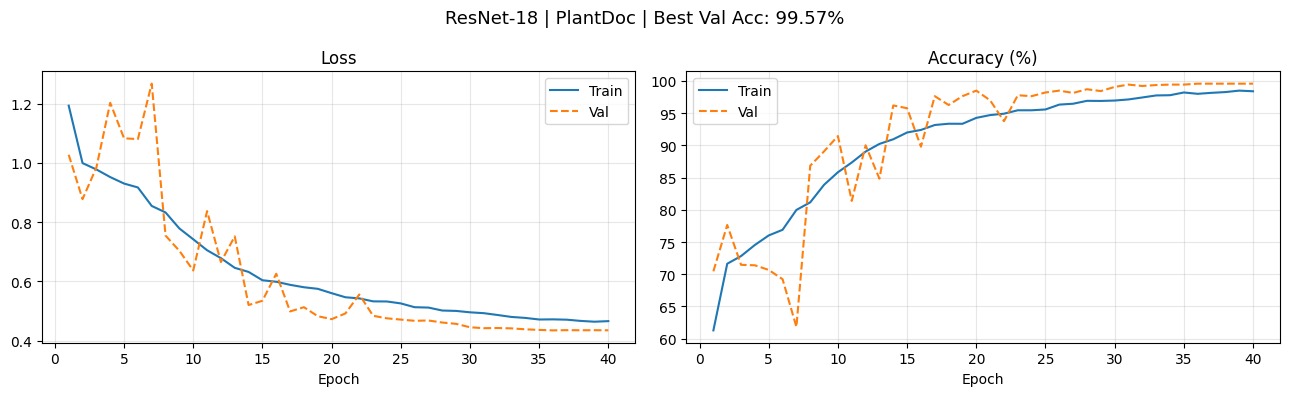

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'ResNet-18 | PlantDoc | Best Val Acc: {best_acc:.2%}', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/NewPlant/resnet18_curves.png', dpi=150)
plt.show()

In [13]:
test_path = os.path.join(DATA_ROOT, 'test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'val')

eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            out = model(imgs.to(DEVICE))
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
overall    = (all_preds == all_labels).float().mean().item()
print(f'\nOverall accuracy on {os.path.basename(eval_path)}: {overall:.4%}\n')

for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')


Overall accuracy on test: 99.2816%

  Bacterial Spot                            99.53%  (n=213)
  Early Blight                              97.51%  (n=241)
  Healthy                                   100.00%  (n=241)
  Late Blight                               99.14%  (n=232)
  Septoria Leaf Spot                        100.00%  (n=219)
  Yellow Leaf Curl Virus                    99.59%  (n=246)


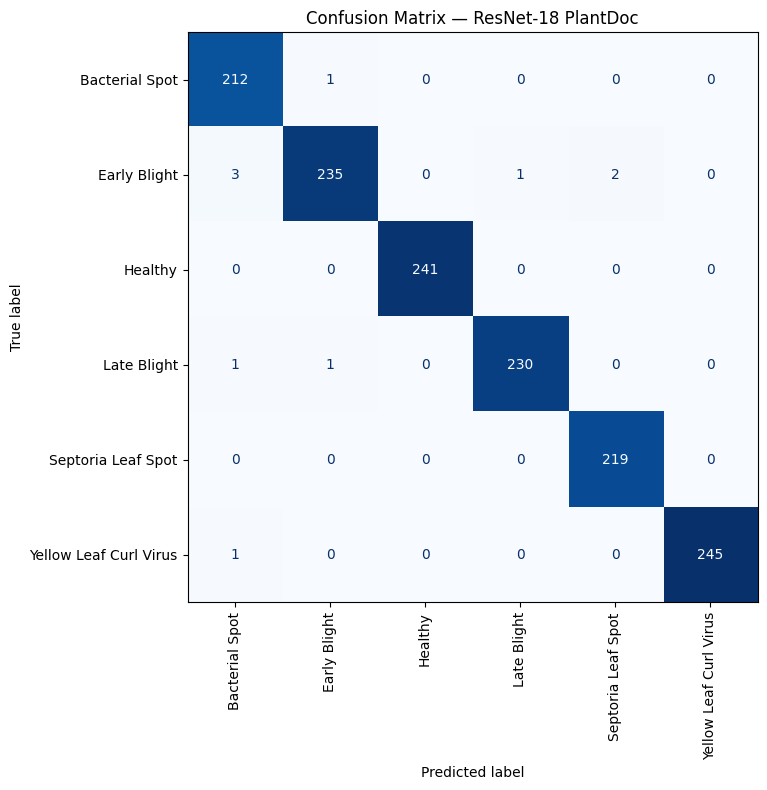

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels.numpy(), all_preds.numpy())
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES//2), max(8, NUM_CLASSES//2)))
ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes).plot(
    ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — ResNet-18 PlantDoc')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/NewPlant/resnet18_cm.png', dpi=120)
plt.show()


In [15]:
from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=eval_ds.classes))

                        precision    recall  f1-score   support

        Bacterial Spot       0.98      1.00      0.99       213
          Early Blight       0.99      0.98      0.98       241
               Healthy       1.00      1.00      1.00       241
           Late Blight       1.00      0.99      0.99       232
    Septoria Leaf Spot       0.99      1.00      1.00       219
Yellow Leaf Curl Virus       1.00      1.00      1.00       246

              accuracy                           0.99      1392
             macro avg       0.99      0.99      0.99      1392
          weighted avg       0.99      0.99      0.99      1392

